In [1]:
import pandas as pd
import seaborn as sns
import sklearn

print("All libraries loaded successfully!")

All libraries loaded successfully!


  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  
Pa

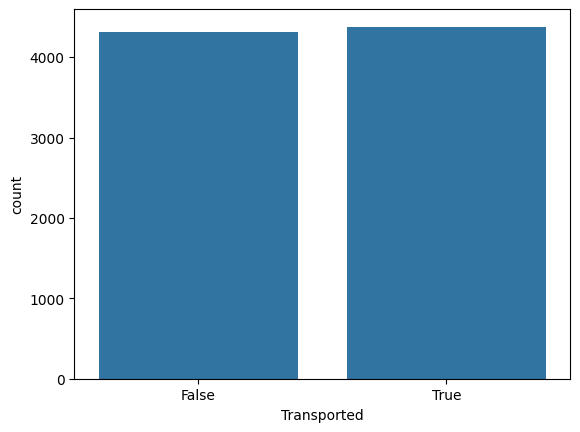

In [2]:

import matplotlib.pyplot as plt

# 1. Load the dataset (assuming the csv is in your folder)
df = pd.read_csv('train.csv')

# 2. See the first 5 rows
print(df.head())

# 3. Check for missing values (crucial for this dataset!)
print(df.isnull().sum())

# 4. Target distribution: How many were transported?
sns.countplot(data=df, x='Transported')
plt.show()



/tmp/ipykernel_311/716670192.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='VIP', y='Age', palette='Set2')


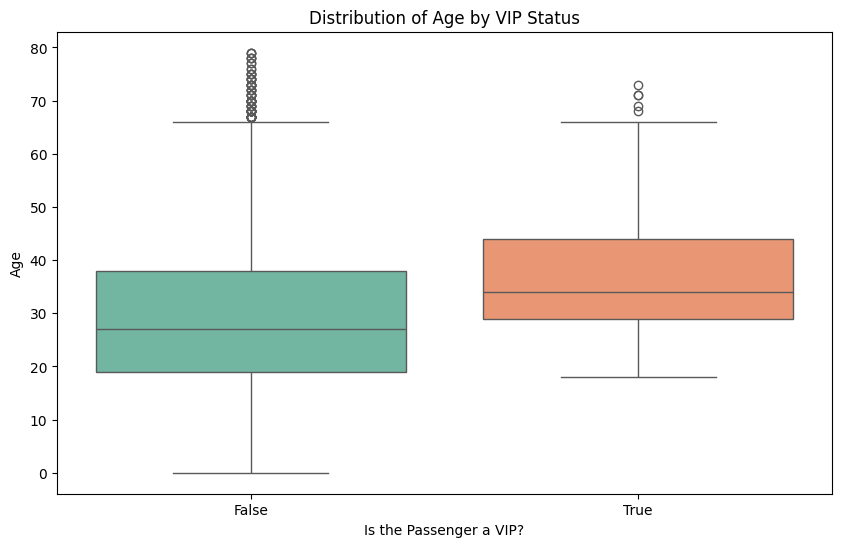

In [3]:
# 1. Load your dataset
df = pd.read_csv('train.csv')

# 2. Create the boxplot
# We use 'VIP' for the x-axis and 'Age' for the y-axis
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='VIP', y='Age', palette='Set2')

# 3. Add titles and labels for clarity
plt.title('Distribution of Age by VIP Status')
plt.xlabel('Is the Passenger a VIP?')
plt.ylabel('Age')

plt.show()

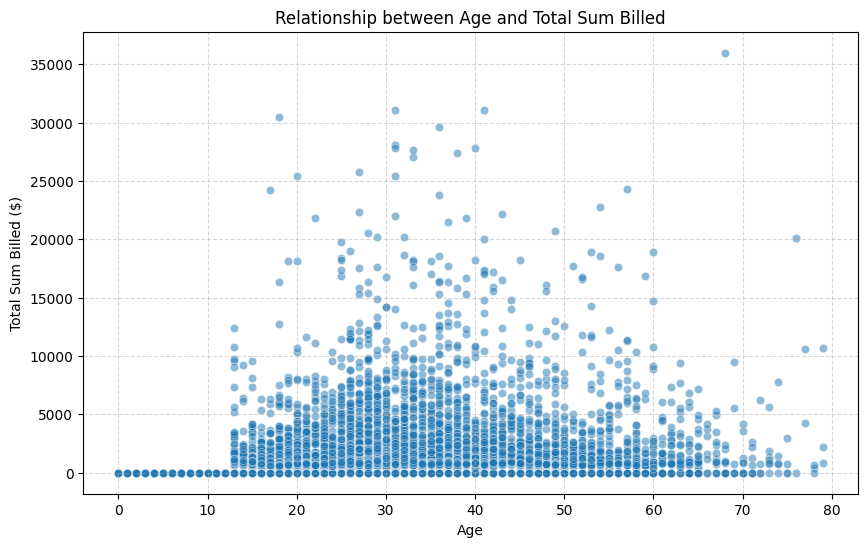

In [4]:
# 1. Load the dataset
df = pd.read_csv('train.csv')

# 2. List the luxury amenity columns
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 3. Calculate the total sum billed per passenger
# axis=1 ensures we sum across the columns for each row
df['TotalSumBilled'] = df[amenities].sum(axis=1)

# 4. Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='TotalSumBilled', alpha=0.5)

# 5. Add titles and labels
plt.title('Relationship between Age and Total Sum Billed')
plt.xlabel('Age')
plt.ylabel('Total Sum Billed ($)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

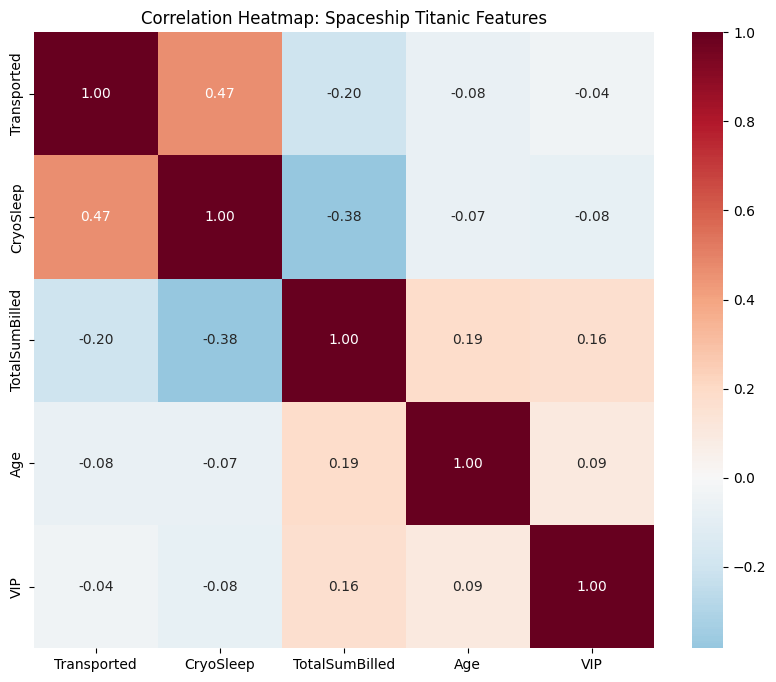

In [5]:
# 2. Preprocess: Sum the billing columns
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['TotalSumBilled'] = df[amenities].sum(axis=1)

# 3. Preprocess: Convert boolean/categorical columns to numeric
# We create a small dataframe with just the columns you requested
cols_of_interest = ['Transported', 'CryoSleep', 'TotalSumBilled', 'Age', 'VIP']
heatmap_data = df[cols_of_interest].copy()

# Convert True/False to 1/0
for col in ['Transported', 'CryoSleep', 'VIP']:
    heatmap_data[col] = heatmap_data[col].astype(float) # float handles NaNs better during conversion

# 4. Calculate the correlation matrix
corr_matrix = heatmap_data.corr()

# 5. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")

plt.title('Correlation Heatmap: Spaceship Titanic Features')
plt.show()

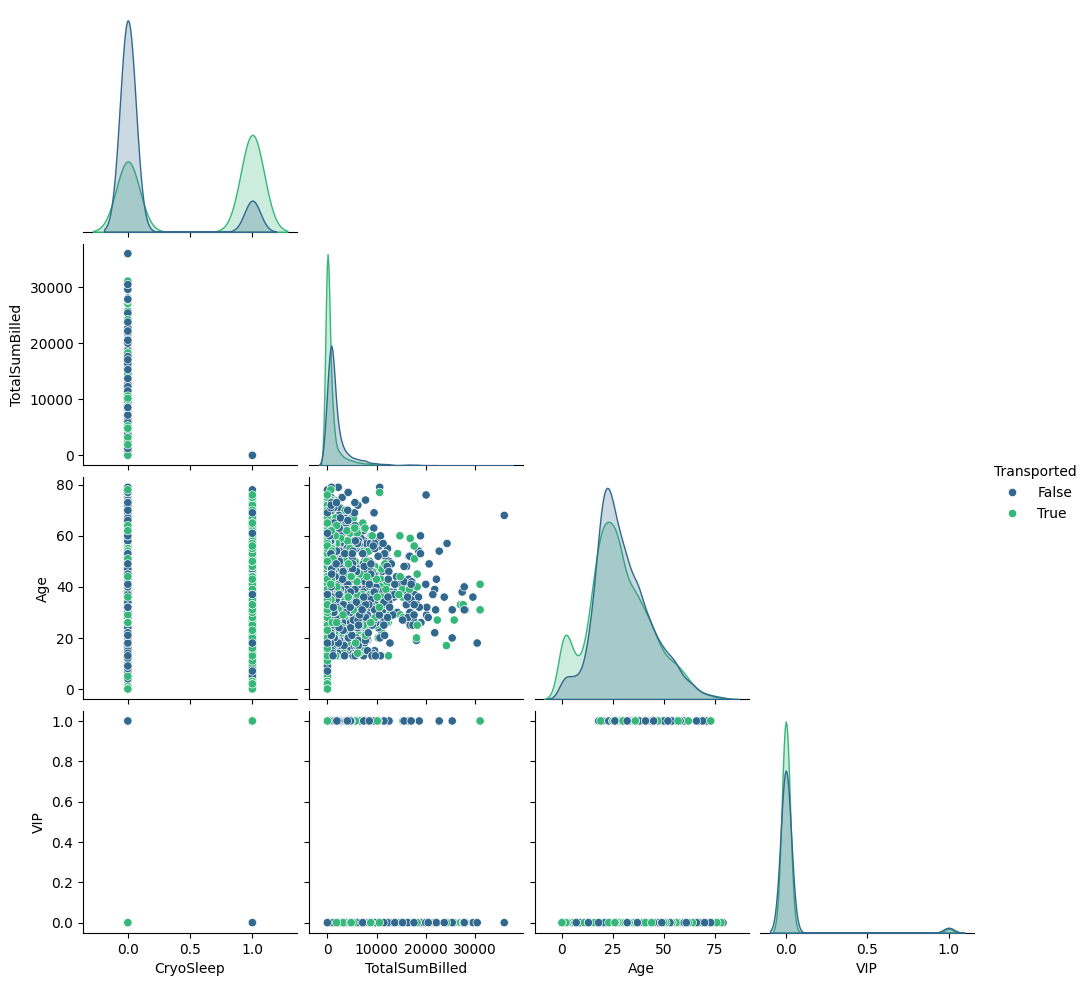

In [6]:
# 1. Load the data
df = pd.read_csv('train.csv')

# 2. Calculate TotalSumBilled
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['TotalSumBilled'] = df[amenities].sum(axis=1)

# 3. Select columns for the pair plot
cols = ['Transported', 'CryoSleep', 'TotalSumBilled', 'Age', 'VIP']
# It is helpful to drop rows with missing values for a cleaner pair plot
plot_df = df[cols].dropna()

# 4. Generate the Pair Plot
# 'corner=True' hides the redundant upper triangle of the matrix
sns.pairplot(plot_df, hue='Transported', corner=True, palette='viridis')

plt.show()

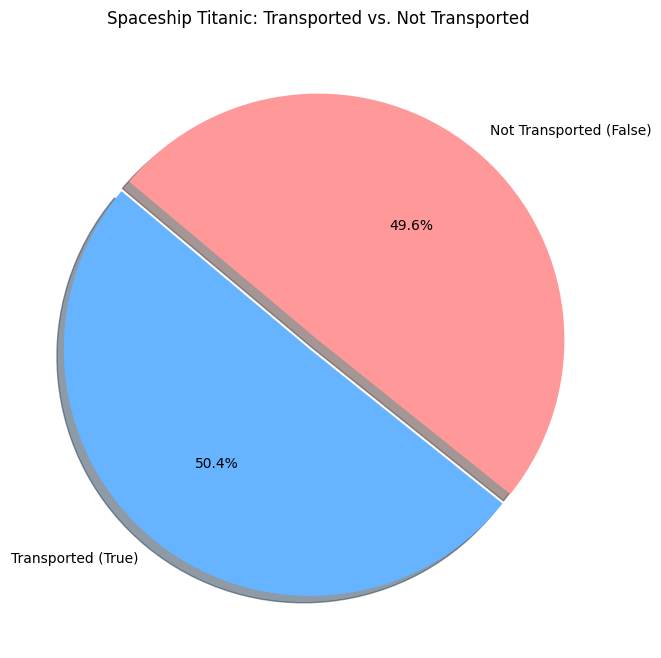

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('train.csv')

# 2. Count the occurrences of each value in the 'Transported' column
transported_counts = df['Transported'].value_counts()

# 3. Create the Pie Chart
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999'] # Blue for True, Pink/Red for False

plt.pie(transported_counts,
        labels=['Transported (True)', 'Not Transported (False)'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0), # Slightly separate the first slice
        shadow=True)

plt.title('Spaceship Titanic: Transported vs. Not Transported')
plt.show()